# MODELIZACIÓN CLASIFICACIÓN PROBABILITY OF DEFAULT

## IMPORTAR PAQUETES

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.metrics import RocCurveDisplay
import scikitplot as skplt
from yellowbrick.classifier import discrimination_threshold

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [11]:
ruta_proyecto = 'C:/Users/Lenovo/Documents/portafolio_ds/automation/SCORING_RIESGOS/'

Nombres de los archivos de datos.

In [12]:
nombre = 'df_tablon_pd.pickle'

Cargar los datos.

In [13]:
df = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre)

In [14]:
df.target_pd.value_counts(normalize=True)

0   0.88
1   0.12
Name: target_pd, dtype: float64

In [15]:
x = df.drop(columns='target_pd')
y = df.target_pd

## MODELIZAR

### Reservar el dataset de validacion

In [20]:
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [21]:
pipe = Pipeline([('algoritmo',LogisticRegression())])

grid = [{'algoritmo': [LogisticRegression(solver = 'saga', n_jobs=-1)],
         'algoritmo__penalty': ['elasticnet', 'l1', 'l2'],
         'algoritmo__C': [0,0.25,0.5,0.75,1]}
       ]

### Optimizar los hiper parámetros

####  Con grid search

In [22]:
grid_search = GridSearchCV(estimator= pipe, 
                           param_grid = grid, 
                           cv = 5, 
                           scoring = 'roc_auc',
                           verbose = 0,
                           n_jobs = -1)

modelo = grid_search.fit(train_x,train_y)

In [23]:
salida = pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score').reset_index(drop=True).head(5)
salida

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.14,0.30,0.02,0.00,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",1,l1,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.70,0.71,0.69,0.69,0.71,0.70,0.01,1
1,2.37,0.44,0.02,0.01,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",0.75,l1,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.70,0.71,0.69,0.69,0.71,0.70,0.01,2
2,2.01,0.07,0.02,0.00,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",0.50,l1,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.70,0.71,0.69,0.69,0.71,0.70,0.01,3
3,7.63,0.65,0.01,0.00,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",1,l2,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.70,0.71,0.69,0.69,0.71,0.70,0.01,4
4,9.49,0.48,0.02,0.00,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",0.75,l2,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.70,0.71,0.69,0.69,0.71,0.70,0.01,5


Vemos que el resultados del auc es el mismo en todas las primeras configuraciones.

Y reentreamos el modelo con esa configuración.

In [24]:
#Instanciar
rl = LogisticRegression(solver = 'saga', n_jobs=-1, C = 1, penalty = 'l1')

#Entrenar
rl.fit(train_x,train_y)

LogisticRegression(C=1, n_jobs=-1, penalty='l1', solver='saga')

Podemos revisar los coefecientes para ver los que son cero y las variables más importantes.

In [25]:
coeficientes = pd.DataFrame(data = rl.coef_, columns = rl.feature_names_in_).stack().droplevel(level = 0).sort_values()
coeficientes

tipo_interes_mms                       -2.20
principal_mms                          -1.80
ingresos_mms                           -1.12
num_cuotas_ 36 months                  -0.30
ingresos_verificados_Not Verified      -0.29
finalidad_house                        -0.17
finalidad_other                        -0.14
vivienda_MORTGAGE                      -0.12
finalidad_car                          -0.11
finalidad_credit_card                  -0.07
finalidad_vacation                     -0.05
antigüedad_empleo_oe_mms               -0.04
finalidad_moving                       -0.00
dti_mms                                 0.00
vivienda_OWN                            0.00
ingresos_verificados_Source Verified    0.00
finalidad_debt_consolidation            0.01
num_cuotas_ 60 months                   0.01
finalidad_home_improvement              0.01
finalidad_otros                         0.03
finalidad_small_business                0.07
finalidad_medical                       0.07
ingresos_v

## EVALUAR

### Predecir sobre validación

In [26]:
pred = rl.predict_proba(val_x)[:, 1]

### Evaluar sobre validación

In [27]:
roc_auc_score(val_y, pred)

0.6987418688289816

## REPORTING DEL MODELO

### Gain Chart

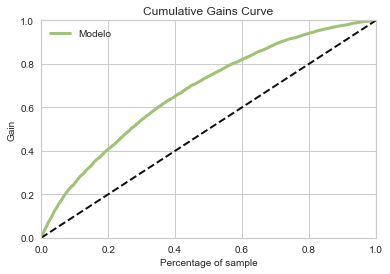

In [28]:
fig, ax = plt.subplots()

skplt.metrics.plot_cumulative_gain(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la línea de los ceros, que internamente tiene etiqueta 'Class 0'
lines = ax.get_lines()
# Buscar por la etiqueta y eliminar la línea correspondiente
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda sin incluir la línea de los ceros
plt.legend(labels=['Modelo'])

# Ahora puedes mostrar el gráfico
plt.show()

### Lift Chart

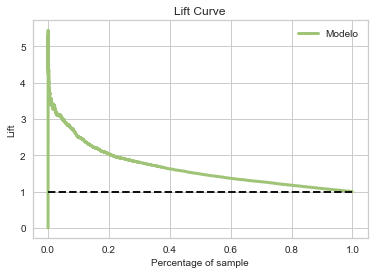

In [31]:
fig, ax = plt.subplots()

skplt.metrics.plot_lift_curve(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la línea de los ceros, que internamente tiene etiqueta 'Class 0'
lines = ax.get_lines()
# Buscar por la etiqueta y eliminar la línea correspondiente
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda sin incluir la línea de los ceros
plt.legend(labels=['Modelo'])

# Ahora puedes mostrar el gráfico
plt.show()

### ROC Chart

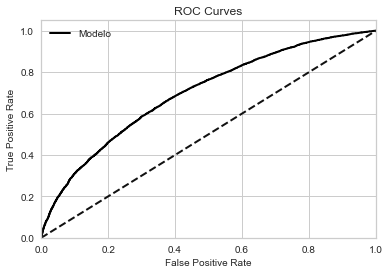

In [30]:
fig, ax = plt.subplots()

# Generamos la gráfica ROC
skplt.metrics.plot_roc(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax)

# Obtenemos todas las líneas y las leyendas
lines = ax.get_lines()

# Recorremos las líneas para eliminar las no deseadas, excepto la línea de la clase 0
for line in lines:
    if 'ROC curve of class 0' in line.get_label():
        line.set_label('Modelo')
    elif line.get_linestyle() != '--':  # Mantenemos la línea punteada pero sin leyenda
        line.set_visible(False)

# Solo añadimos al leyenda la línea de la clase 0 renombrada a 'Modelo'
handles, labels = ax.get_legend_handles_labels()
new_handles = [h for h, l in zip(handles, labels) if l == 'Modelo']
new_labels = ['Modelo']

ax.legend(new_handles, new_labels, loc='best')

# Ahora puedes mostrar el gráfico
plt.show();